In [8]:
import numpy as np
import pandas as pd

SAVE_DIR = "saved_analysis_states"

state_table    = pd.read_parquet(f"{SAVE_DIR}/state_table.parquet")
clusters_df = pd.read_parquet(f"{SAVE_DIR}/customer_cluster_assignments.parquet")
cluster_profile_df = clusters_df.merge(
    state_table,
    on="customer_id",
    how="left"
)
print(state_table.columns)
print(clusters_df.columns)
print(cluster_profile_df.columns)

Index(['customer_id', 'snapshot_date', 'first_purchase_date',
       'last_purchase_date', 'frequency', 'repeat_frequency', 'total_revenue',
       'avg_order_value', 'std_order_value', 'tenure_days', 'recency_days',
       'avg_gap_days', 'std_gap_days', 'max_gap_days', 'unique_products_total',
       'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new',
       'is_dormant', 'purchase_regularity', 'revenue_volatility', 'country',
       'future_purchase_count', 'future_revenue', 'future_avg_order_value',
       'had_activity'],
      dtype='object')
Index(['customer_id', 'cluster', 'split'], dtype='object')
Index(['customer_id', 'cluster', 'split', 'snapshot_date',
       'first_purchase_date', 'last_purchase_date', 'frequency',
       'repeat_frequency', 'total_revenue', 'avg_order_value',
       'std_order_value', 'tenure_days', 'recency_days', 'avg_gap_days',
       'std_gap_days', 'max_gap_days', 'unique_products_total',
       'avg_unique_products', 'orders_last

In [9]:

feature_cols = [
    "recency_days",
    "frequency",
    "total_revenue", "avg_order_value",
    "tenure_days",
    "avg_unique_products",
    "revenue_volatility",
]

cluster_summary = cluster_profile_df.groupby("cluster")[feature_cols].agg(["mean", "median"])
cluster_summary.columns = ["_".join(col) for col in cluster_summary.columns]

cluster_sizes = cluster_profile_df.groupby("cluster").size().rename("n_customers")
cluster_sizes_pct = (cluster_sizes / cluster_sizes.sum() * 100).round(1).rename("pct_of_total")

cluster_summary = pd.concat([cluster_sizes, cluster_sizes_pct, cluster_summary], axis=1)

pd.set_option("display.max_columns", None)
print(cluster_summary.round(2))


         n_customers  pct_of_total  recency_days_mean  recency_days_median  \
cluster                                                                      
0                179           3.8              14.08                 13.0   
1               1596          33.8             128.69                120.0   
2                472          10.0             130.80                135.0   
3                691          14.7              11.95                 10.0   
4               1778          37.7             234.41                197.0   

         frequency_mean  frequency_median  total_revenue_mean  \
cluster                                                         
0                  1.14               1.0              435.40   
1                  6.19               5.0             2462.71   
2                  2.33               2.0              662.30   
3                 14.11               9.0             8129.87   
4                  1.24               1.0              380.79  

In [10]:
population_median = cluster_profile_df[feature_cols].median()

median_cols = [f"{c}_median" for c in feature_cols]
cluster_medians = cluster_summary[median_cols].copy()
cluster_medians.columns = feature_cols  # strip suffix for clean division

index_table = (cluster_medians / population_median * 100).round(1)

print("Population medians:")
print(population_median.round(2))
print("\nCluster index (100 = population median):")
print(index_table)

Population medians:
recency_days           129.00
frequency                2.00
total_revenue          710.79
avg_order_value        280.02
tenure_days            342.00
avg_unique_products     17.00
revenue_volatility       0.29
dtype: float64

Cluster index (100 = population median):
         recency_days  frequency  total_revenue  avg_order_value  tenure_days  \
cluster                                                                         
0                10.1       50.0           42.3            106.6          4.1   
1                93.0      250.0          216.4            109.6        115.8   
2               104.7      100.0           74.7             82.9        114.6   
3                 7.8      450.0          462.1            124.0        123.4   
4               152.7       50.0           38.2             79.5         61.8   

         avg_unique_products  revenue_volatility  
cluster                                           
0                      105.9               

In [14]:
# Rank each cluster's features by |deviation from 100|, keep the top 4 as the
# defining traits for persona naming (not all 7 features — keeps narrative tight)

deviation = index_table - 100
top_n = 4

for cluster_id, row in deviation.iterrows():
    ranked = row.abs().sort_values(ascending=False)
    top_features = ranked.index[:top_n]

    size = int(cluster_summary.loc[cluster_id, "n_customers"])
    pct = cluster_summary.loc[cluster_id, "pct_of_total"]

    print(f"Cluster {cluster_id}  (n={size}, {pct}% of customers)")
    for feat in top_features:
        idx_val = index_table.loc[cluster_id, feat]
        direction = "above" if idx_val > 100 else "below"
        print(f"   - {feat}: index={idx_val:.1f}  ({direction} population median)")
    print()

Cluster 0  (n=179, 3.8% of customers)
   - revenue_volatility: index=0.0  (below population median)
   - tenure_days: index=4.1  (below population median)
   - recency_days: index=10.1  (below population median)
   - total_revenue: index=42.3  (below population median)

Cluster 1  (n=1596, 33.8% of customers)
   - frequency: index=250.0  (above population median)
   - total_revenue: index=216.4  (above population median)
   - revenue_volatility: index=180.1  (above population median)
   - tenure_days: index=115.8  (above population median)

Cluster 2  (n=472, 10.0% of customers)
   - total_revenue: index=74.7  (below population median)
   - avg_order_value: index=82.9  (below population median)
   - revenue_volatility: index=115.3  (above population median)
   - tenure_days: index=114.6  (above population median)

Cluster 3  (n=691, 14.7% of customers)
   - total_revenue: index=462.1  (above population median)
   - frequency: index=450.0  (above population median)
   - recency_days: in

In [15]:
persona_map = {
    0: {
        "persona_name": "Emerging Customers",
        "description": ("Brand-new customers (lowest tenure, very recent first purchase). "
                         "Revenue is still low simply due to short history, not low value -- "
                         "too early to judge long-term worth."),
    },
    1: {
        "persona_name": "Established Customers",
        "description": ("Largest high-value segment: strong frequency, revenue, and tenure, "
                         "but recency is near the population median and most are flagged "
                         "dormant -- engagement is starting to fade."),
    },
    2: {
        "persona_name": "At-risk Customers",
        "description": ("Long-tenured but never high-value -- below-average revenue and order "
                         "size, majority dormant. Chronic low engagement rather than recent churn."),
    },
    3: {
        "persona_name": "Premium Customers",
        "description": ("Highest revenue and frequency by a wide margin, most recently active, "
                         "zero dormancy. The clear high-value core of the customer base."),
    },
    4: {
        "persona_name": "Lapsed One-Time Buyers",
        "description": ("Largest segment overall. Longest gap since last purchase, mostly "
                         "single-order customers with no repeat behavior."),
    },
}

persona_summary = cluster_summary[["n_customers", "pct_of_total"]].copy()
persona_summary["persona_name"] = persona_summary.index.map(lambda c: persona_map[c]["persona_name"])
persona_summary["description"] = persona_summary.index.map(lambda c: persona_map[c]["description"])

trait_strings = {}
for cluster_id, row in deviation.iterrows():
    ranked = row.abs().sort_values(ascending=False)
    top_features = ranked.index[:4]
    trait_strings[cluster_id] = "; ".join(
        f"{feat}={index_table.loc[cluster_id, feat]:.0f}" for feat in top_features
    )
persona_summary["top_traits_index"] = persona_summary.index.map(trait_strings)

persona_summary = persona_summary.reset_index()
print(persona_summary)

persona_summary.to_parquet(f"{SAVE_DIR}/cluster_persona_summary.parquet", index=False)
persona_summary.to_csv(f"{SAVE_DIR}/cluster_persona_summary.csv", index=False)
print("\nSaved to", SAVE_DIR)

   cluster  n_customers  pct_of_total            persona_name  \
0        0          179           3.8      Emerging Customers   
1        1         1596          33.8   Established Customers   
2        2          472          10.0       At-risk Customers   
3        3          691          14.7       Premium Customers   
4        4         1778          37.7  Lapsed One-Time Buyers   

                                         description  \
0  Brand-new customers (lowest tenure, very recen...   
1  Largest high-value segment: strong frequency, ...   
2  Long-tenured but never high-value -- below-ave...   
3  Highest revenue and frequency by a wide margin...   
4  Largest segment overall. Longest gap since las...   

                                    top_traits_index  
0  revenue_volatility=0; tenure_days=4; recency_d...  
1  frequency=250; total_revenue=216; revenue_vola...  
2  total_revenue=75; avg_order_value=83; revenue_...  
3  total_revenue=462; frequency=450; recency_days...

In [16]:
future_cols = ["future_revenue", "future_purchase_count", "future_avg_order_value"]

future_summary = cluster_profile_df.groupby("cluster").agg(
    future_revenue_mean=("future_revenue", "mean"),
    future_purchase_count_mean=("future_purchase_count", "mean"),
    future_avg_order_value_mean=("future_avg_order_value", "mean"),
    retention_rate=("had_activity", "mean"),
)

population_future_mean = cluster_profile_df[future_cols].mean()

future_index = future_summary[[f"{c}_mean" for c in future_cols]].copy()
for c in future_cols:
    future_index[f"{c}_mean"] = future_index[f"{c}_mean"] / population_future_mean[c] * 100
future_index.columns = [f"{c}_index" for c in future_cols]

future_lift = (future_index - 100).round(1)
future_lift.columns = [c.replace("_index", "_lift_pct") for c in future_lift.columns]

validity_table = persona_summary[["cluster", "persona_name"]].set_index("cluster")
validity_table = (validity_table
                   .join(future_summary)
                   .join(future_index)
                   .join(future_lift))
validity_table["future_value_rank"] = (
    validity_table["future_revenue_mean"].rank(ascending=False).astype(int)
)

print(validity_table.round(2))

                   persona_name  future_revenue_mean  \
cluster                                                
0            Emerging Customers               528.34   
1         Established Customers               599.30   
2             At-risk Customers               189.12   
3             Premium Customers              2965.71   
4        Lapsed One-Time Buyers               105.28   

         future_purchase_count_mean  future_avg_order_value_mean  \
cluster                                                            
0                              1.57                       181.61   
1                              1.47                       250.65   
2                              0.59                       120.53   
3                              4.92                       409.58   
4                              0.36                        67.95   

         retention_rate  future_revenue_index  future_purchase_count_index  \
cluster                                             

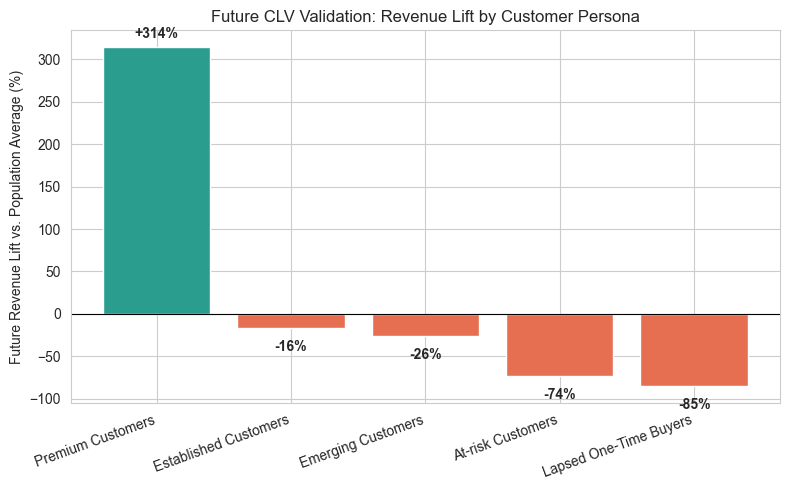

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plot_df = validity_table.sort_values("future_value_rank").reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in plot_df["future_revenue_lift_pct"]]
bars = ax.bar(plot_df["persona_name"], plot_df["future_revenue_lift_pct"], color=colors)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Future Revenue Lift vs. Population Average (%)")
ax.set_xlabel("")
ax.set_title("Future CLV Validation: Revenue Lift by Customer Persona")

for bar, val in zip(bars, plot_df["future_revenue_lift_pct"]):
    offset = 8 if val >= 0 else -14
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset, f"{val:+.0f}%",
             ha="center", va="bottom" if val >= 0 else "top", fontsize=10, fontweight="bold")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/persona_future_revenue_lift.png", dpi=200, bbox_inches="tight")
plt.show()